## Imports

In [5]:
import torch
import matplotlib.pyplot as plt
from torchvision.transforms import ToTensor
from PIL import Image
from models.models import OVIEModel
from utils.pose_enc import extri_intri_to_pose_encoding

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Model loading

In [ ]:
REVISION = "v1.0"  # pin to a specific tagged release

model = OVIEModel.from_pretrained("kyutai/ovie", revision=REVISION).to(device)
model.eval()
image_size = model.image_size
print(f"Total number of parameters: {sum(p.numel() for p in model.parameters()):,}")

## Scene preparation

In [7]:
# load image
image_path = "./assets/sample_image.jpg"
img_pil = Image.open(image_path).convert("RGB").resize((image_size, image_size))
img_tensor = ToTensor()(img_pil).unsqueeze(0).to(device)  # (1, 3, H, W)

# build desired viewpoint
extrinsics = torch.tensor(
    [[[1.0, 0.0, 0.0, -1.25], [0.0, 1.0, 0.0, 0.5], [0.0, 0.0, 1.0, -2.0]]],
    device=device,
)  # (1, 3, 4)

dummy_intrinsics = torch.zeros(1, 1, 3, 3, device=device)

# build camera token
camera = extri_intri_to_pose_encoding(
    extrinsics=extrinsics.unsqueeze(0),
    intrinsics=dummy_intrinsics,
    image_size_hw=(image_size, image_size),
)
cam_token = camera[..., :7].squeeze(0)

## View synthesis and display

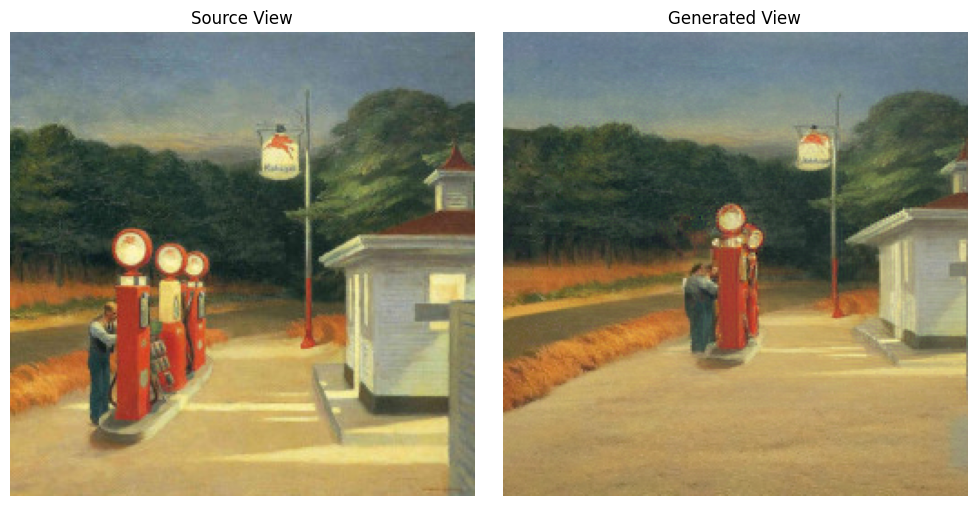

In [8]:
# inference
with torch.no_grad():
    pred_tensor = model(x=img_tensor, cam_params=cam_token)


src_display = img_tensor[0, :3].cpu().permute(1, 2, 0).numpy()
pred_display = pred_tensor[0].cpu().clamp(0, 1).permute(1, 2, 0).numpy()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(src_display)
axes[0].set_title("Source View")
axes[0].axis("off")

axes[1].imshow(pred_display)
axes[1].set_title("Generated View")
axes[1].axis("off")

plt.tight_layout()
plt.show()